In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 100)
np.random.seed(42)

In [ ]:
df = pd.DataFrame({
    "timestamp": ["2026-08-20 09:00:00", "2026-08-20 09:01:00", "2026-08-20 09:02:00", "2026-08-20 09:03:00"],
    "source": ["api", "db", "api", "worker"],
    "level": ["INFO", "ERROR", "WARN", "ERROR"],
    "duration_ms": ["120", "350", "bad", "80"],
    "bytes": [1024, 2048, 512, None],
    "msg": ["start", "timeout", "cache hit", "retry"]
})

display(df)

,timestamp,source,level,duration_ms,bytes,msg
0,2026-08-20 09:00:00,api,INFO,120,1024.0,start
1,2026-08-20 09:01:00,db,ERROR,350,2048.0,timeout
2,2026-08-20 09:02:00,api,WARN,bad,512.0,cache hit
3,2026-08-20 09:03:00,worker,ERROR,80,NaN,retry


In [4]:
clean_df = df.copy()
clean_df["timestamp"] = pd.to_datetime(clean_df["timestamp"], errors="coerce")
clean_df["duration_ms"] = pd.to_numeric(clean_df["duration_ms"], errors="coerce")
clean_df["bytes"] = pd.to_numeric(clean_df["bytes"], errors="coerce")
clean_df["is_error"] = clean_df["level"].eq("ERROR")
clean_df["hour"] = clean_df["timestamp"].dt.hour
clean_df["duration_bucket"] = pd.cut(
    clean_df["duration_ms"],
    bins=[0, 100, 200, 300, 500, np.inf],
    labels=["0-100", "100-200", "200-300", "300-500", "500+"],
    right=False
)

display(clean_df)
display("缺失统计：")
display(clean_df.isna().sum())

,timestamp,source,level,duration_ms,bytes,msg,is_error,hour,duration_bucket
0,2026-08-20 09:00:00,api,INFO,120.0,1024.0,start,False,9,100-200
1,2026-08-20 09:01:00,db,ERROR,350.0,2048.0,timeout,True,9,300-500
2,2026-08-20 09:02:00,api,WARN,NaN,512.0,cache hit,False,9,NaN
3,2026-08-20 09:03:00,worker,ERROR,80.0,NaN,retry,True,9,0-100


'缺失统计：'

timestamp          0
source             0
level              0
duration_ms        1
bytes              1
msg                0
is_error           0
hour               0
duration_bucket    1
dtype: int64

In [5]:
error_rate = (
    clean_df
    .assign(duration_ms=clean_df["duration_ms"])
    .groupby("source", dropna=False)["is_error"]
    .mean()
    .sort_values(ascending=False)
)
print(error_rate)

q95 = clean_df["duration_ms"].quantile(0.95)
print("全局95分位:", q95)

source
db        1.0
worker    1.0
api       0.0
Name: is_error, dtype: float64
全局95分位: 327.0


,source,level,sample_count,avg_duration,median_duration,p95_duration
0,api,INFO,1,120.0,120.0,120.0
1,api,WARN,0,NaN,NaN,NaN
2,db,ERROR,1,350.0,350.0,350.0
3,worker,ERROR,1,80.0,80.0,80.0


level,ERROR,INFO
source,,
api,NaN,120.0
db,350.0,NaN
worker,80.0,NaN


hour
9    0.5
Name: error_rate, dtype: float64

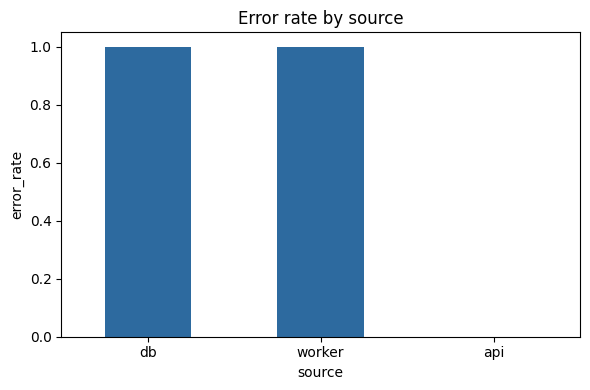

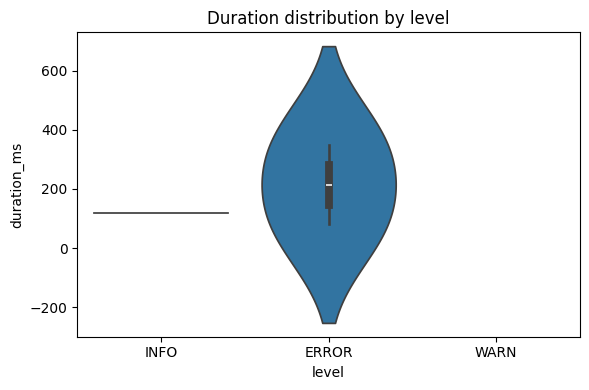

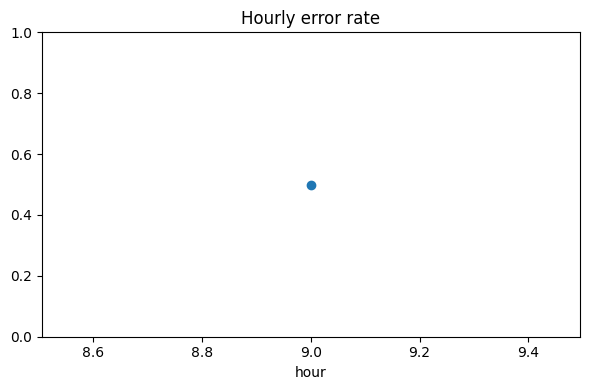

In [6]:
# 1) 按 source + level 的核心指标透视
summary = (
    clean_df.groupby(["source", "level"], as_index=False)
    .agg(
        sample_count=("duration_ms", "count"),
        avg_duration=("duration_ms", "mean"),
        median_duration=("duration_ms", "median"),
        p95_duration=("duration_ms", lambda s: s.quantile(0.95)),
    )
)
display(summary)

# 2) 构造 source x level 的透视表（便于横向比较）
pivot = clean_df.pivot_table(
    index="source",
    columns="level",
    values="duration_ms",
    aggfunc="mean",
)
display(pivot)

# 3) 按小时错误率（虽然本例只有一个小时，但先建立流程）
hourly = clean_df.groupby("hour")["is_error"].mean().rename("error_rate")
display(hourly)

# 4) 画三类图（每张图后面配一句结论）
# (a) source 错误率
err_by_source = clean_df.groupby("source")["is_error"].mean().sort_values(ascending=False)
plt.figure(figsize=(6, 4))
err_by_source.plot(kind="bar", color="#2d6a9f")
plt.title("Error rate by source")
plt.ylabel("error_rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# (b) level 与时延分布
plt.figure(figsize=(6, 4))
sns.violinplot(data=clean_df, x="level", y="duration_ms")
plt.title("Duration distribution by level")
plt.tight_layout()
plt.show()

# (c) 小时错误率趋势
plt.figure(figsize=(6, 4))
hourly.plot(kind="line", marker="o")
plt.title("Hourly error rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [8]:
slow_logs = (
    clean_df
    .loc[clean_df["duration_ms"] > q95]
    .sort_values("duration_ms", ascending=False)
)

display(slow_logs)

,timestamp,source,level,duration_ms,bytes,msg,is_error,hour,duration_bucket
1,2026-08-20 09:01:00,db,ERROR,350.0,2048.0,timeout,True,9,300-500


In [9]:
source_q95 = (
    clean_df
    .groupby("source")["duration_ms"]
    .quantile(0.95)
    .rename("source_q95")
)

display(source_q95)

source
api       120.0
db        350.0
worker     80.0
Name: source_q95, dtype: float64

In [10]:
clean_df = clean_df.merge(
    source_q95,
    left_on="source",
    right_index=True,
    how="left"
)

display(
    clean_df[
        ["source", "duration_ms", "source_q95"]
    ]
)

,source,duration_ms,source_q95
0,api,120.0,120.0
1,db,350.0,350.0
2,api,NaN,120.0
3,worker,80.0,80.0


In [11]:
clean_df["is_source_slow"] = (
    clean_df["duration_ms"] > clean_df["source_q95"]
)

display(
    clean_df[
        ["source", "duration_ms", "source_q95", "is_source_slow"]
    ]
)

,source,duration_ms,source_q95,is_source_slow
0,api,120.0,120.0,False
1,db,350.0,350.0,False
2,api,NaN,120.0,False
3,worker,80.0,80.0,False


In [12]:
clean_df["is_global_slow"] = clean_df["duration_ms"] > q95

display(
    clean_df[
        [
            "source",
            "duration_ms",
            "is_error",
            "is_global_slow",
            "msg",
        ]
    ]
)

,source,duration_ms,is_error,is_global_slow,msg
0,api,120.0,False,False,start
1,db,350.0,True,True,timeout
2,api,NaN,False,False,cache hit
3,worker,80.0,True,False,retry


In [13]:
critical_logs = clean_df.loc[
    clean_df["is_error"] & clean_df["is_global_slow"]
]

display(
    critical_logs[
        ["timestamp", "source", "duration_ms", "msg"]
    ]
)

,timestamp,source,duration_ms,msg
1,2026-08-20 09:01:00,db,350.0,timeout


In [14]:
clean_df["priority"] = np.select(
    [
        clean_df["is_error"] & clean_df["is_global_slow"],
        clean_df["is_error"],
        clean_df["is_global_slow"],
    ],
    [
        "critical",
        "error",
        "slow",
    ],
    default="normal",
)

display(
    clean_df[
        [
            "source",
            "level",
            "duration_ms",
            "msg",
            "priority",
        ]
    ]
)

,source,level,duration_ms,msg,priority
0,api,INFO,120.0,start,normal
1,db,ERROR,350.0,timeout,critical
2,api,WARN,NaN,cache hit,normal
3,worker,ERROR,80.0,retry,error


In [16]:
clean_df["has_data_issue"] = clean_df["duration_ms"].isna()

display(
    clean_df[
        [
            "source",
            "level",
            "duration_ms",
            "msg",
            "priority",
            "has_data_issue",
        ]
    ]
)

valid_duration_logs = clean_df.loc[
    clean_df["duration_ms"].notna()
]

display(valid_duration_logs)

,source,level,duration_ms,msg,priority,has_data_issue
0,api,INFO,120.0,start,normal,False
1,db,ERROR,350.0,timeout,critical,False
2,api,WARN,NaN,cache hit,normal,True
3,worker,ERROR,80.0,retry,error,False


,timestamp,source,level,duration_ms,bytes,msg,is_error,hour,duration_bucket,source_q95,is_source_slow,is_global_slow,priority,has_data_issue
0,2026-08-20 09:00:00,api,INFO,120.0,1024.0,start,False,9,100-200,120.0,False,False,normal,False
1,2026-08-20 09:01:00,db,ERROR,350.0,2048.0,timeout,True,9,300-500,350.0,False,True,critical,False
3,2026-08-20 09:03:00,worker,ERROR,80.0,NaN,retry,True,9,0-100,80.0,False,False,error,False


In [17]:
attention_logs = (
    clean_df
    .loc[
        (clean_df["priority"] != "normal")
        | clean_df["has_data_issue"]
    ]
    .sort_values(
        ["is_global_slow", "is_error"],
        ascending=[False, False],
    )
)

display(
    attention_logs[
        [
            "timestamp",
            "source",
            "level",
            "duration_ms",
            "msg",
            "priority",
            "has_data_issue",
        ]
    ]
)

,timestamp,source,level,duration_ms,msg,priority,has_data_issue
1,2026-08-20 09:01:00,db,ERROR,350.0,timeout,critical,False
3,2026-08-20 09:03:00,worker,ERROR,80.0,retry,error,False
2,2026-08-20 09:02:00,api,WARN,NaN,cache hit,normal,True


In [18]:
summary = pd.Series({
    "total_logs": len(clean_df),
    "error_logs": clean_df["is_error"].sum(),
    "global_slow_logs": clean_df["is_global_slow"].sum(),
    "critical_logs": (clean_df["priority"] == "critical").sum(),
    "data_issue_logs": clean_df["has_data_issue"].sum(),
    "error_rate": clean_df["is_error"].mean(),
})

display(summary)

total_logs          4.0
error_logs          2.0
global_slow_logs    1.0
critical_logs       1.0
data_issue_logs     1.0
error_rate          0.5
dtype: float64

In [19]:
priority_summary = (
    clean_df["priority"]
    .value_counts()
    .rename_axis("priority")
    .reset_index(name="log_count")
)

display(priority_summary)

,priority,log_count
0,normal,2
1,critical,1
2,error,1


In [23]:
output_columns = [
    "timestamp",
    "source",
    "level",
    "duration_ms",
    "bytes",
    "msg",
    "priority",
    "has_data_issue",
]

attention_logs[output_columns].to_csv(
    "attention_logs.csv",
    index=False,
    encoding="utf-8-sig",
)

exported_logs = pd.read_csv(
    "attention_logs.csv",
    parse_dates=["timestamp"],
)

display(exported_logs)

exported_logs.info()

,timestamp,source,level,duration_ms,bytes,msg,priority,has_data_issue
0,2026-08-20 09:01:00,db,ERROR,350.0,2048.0,timeout,critical,False
1,2026-08-20 09:03:00,worker,ERROR,80.0,NaN,retry,error,False
2,2026-08-20 09:02:00,api,WARN,NaN,512.0,cache hit,normal,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       3 non-null      datetime64[ns]
 1   source          3 non-null      object        
 2   level           3 non-null      object        
 3   duration_ms     2 non-null      float64       
 4   bytes           2 non-null      float64       
 5   msg             3 non-null      object        
 6   priority        3 non-null      object        
 7   has_data_issue  3 non-null      bool          
dtypes: bool(1), datetime64[ns](1), float64(2), object(4)
memory usage: 303.0+ bytes


In [24]:
display(exported_logs.shape)

display(exported_logs["duration_ms"].isna().sum())

display(
    exported_logs.loc[
        exported_logs["priority"] == "critical",
        ["source", "msg"],
    ]
)

,source,msg
0,db,timeout


In [27]:
api_attention = exported_logs.loc[
    (exported_logs["source"] == "api")
    & ((exported_logs["priority"] != "normal")|(exported_logs["has_data_issue"])),
    [
        "timestamp",
        "level",
        "msg",
        "priority",
        "has_data_issue",
    ],
]

display(api_attention)

,timestamp,level,msg,priority,has_data_issue
2,2026-08-20 09:02:00,WARN,cache hit,normal,True


In [28]:
source_summary = (
    exported_logs
    .groupby("source")
    .agg(
        log_count=("source", "size"),
        avg_duration=("duration_ms", "mean"),
    )
    .reset_index()
)

display(source_summary)

,source,log_count,avg_duration
0,api,1,NaN
1,db,1,350.0
2,worker,1,80.0


In [31]:
source_summary = (
    exported_logs
    .groupby("source")
    .agg(
        log_count=("source", "size"),
        valid_duration_count=("duration_ms", "count"),
        avg_duration=("duration_ms", "mean"),
    )
    .reset_index()
)

display(source_summary)

source_summary["duration_complete_rate"] = (
    source_summary["valid_duration_count"]
    / source_summary["log_count"]
)

display(source_summary)

,source,log_count,valid_duration_count,avg_duration
0,api,1,0,NaN
1,db,1,1,350.0
2,worker,1,1,80.0


,source,log_count,valid_duration_count,avg_duration,duration_complete_rate
0,api,1,0,NaN,0.0
1,db,1,1,350.0,1.0
2,worker,1,1,80.0,1.0


In [32]:
incomplete_sources = (
    source_summary
    .loc[
        source_summary["duration_complete_rate"] < 1.0
    ]
    .sort_values(
        "duration_complete_rate",
        ascending=True,
    )
)

display(incomplete_sources)

,source,log_count,valid_duration_count,avg_duration,duration_complete_rate
0,api,1,0,NaN,0.0
